# Atividade de vendas no Brasil

Nesta atividade vamos explorar um dataset de vendas no Brasil, praticando **NumPy**, **Pandas** e **Seaborn**.

O notebook está organizado em três entregáveis:

- **Entregável 1 — NumPy**: cálculos numéricos e operações vetorizadas
- **Entregável 2 — Pandas**: leitura, limpeza, transformação e agrupamento dos dados
- **Entregável 3 — Seaborn**: visualizações e interpretação dos gráficos

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("vendas_brasil.csv")
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,22.31,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,30.26,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,21.61,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,41.27,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,9.47,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


## Entregável 1 — NumPy

Nesta parte, o foco é usar **NumPy** para cálculos numéricos, operações vetorizadas, máscaras booleanas e agregações.

### A. Criando arrays

Vamos extrair algumas colunas numéricas do dataset como arrays NumPy.

In [2]:
preco_unitario = df["preco_unitario"].to_numpy()
custo_unitario = df["custo_unitario"].to_numpy()
quantidade = df["quantidade"].to_numpy()
desconto_pct = df["desconto_pct"].to_numpy()
receita_total = df["receita_total"].to_numpy()
frete = df["frete"].to_numpy()

print("preco_unitario:", preco_unitario[:5])
print("custo_unitario:", custo_unitario[:5])
print("quantidade:", quantidade[:5])
print("desconto_pct:", desconto_pct[:5])
print("receita_total:", receita_total[:5])
print("frete:", frete[:5])
print("\nFormato de cada array:", preco_unitario.shape)

preco_unitario: [739.39 187.48  76.11 145.86 133.92]
custo_unitario: [561.75 135.15  61.4   88.53 107.25]
quantidade: [10  5 14 11  1]
desconto_pct: [ 5.2  0.6  0.7  0.6 19.5]
receita_total: [6933.48  930.28 1058.5  1592.43  107.64]
frete: [ 8.68   nan  7.98 20.49 22.89]

Formato de cada array: (37617,)


**Observação:** todas as colunas viraram arrays NumPy de uma dimensão (shape `(37617,)`), prontos para operações vetorizadas. A coluna `frete` tem valores faltantes (`NaN`), que serão tratados no Entregável 2.

### B. Cálculos com operações vetorizadas

Agora vamos calcular novas informações usando os arrays criados, sem laços `for`.

In [3]:
valor_bruto = preco_unitario * quantidade
valor_desconto = valor_bruto * (desconto_pct / 100)
custo_total = custo_unitario * quantidade
lucro_estimado = valor_bruto - valor_desconto - custo_total

print("Valor bruto da venda   :", valor_bruto[:5])
print("Valor do desconto      :", valor_desconto[:5])
print("Custo total            :", custo_total[:5])
print("Lucro estimado         :", lucro_estimado[:5])

Valor bruto da venda   : [7393.9   937.4  1065.54 1604.46  133.92]
Valor do desconto      : [384.4828    5.6244    7.45878   9.62676  26.1144 ]
Custo total            : [5617.5   675.75  859.6   973.83  107.25]
Lucro estimado         : [1.3919172e+03 2.5602560e+02 1.9848122e+02 6.2100324e+02 5.5560000e-01]


**Observação:** o `valor_bruto` é o preço unitário multiplicado pela quantidade; o `valor_desconto` aplica o percentual de desconto sobre o valor bruto; o `custo_total` usa o custo unitário; e o `lucro_estimado` é o valor bruto menos o desconto e menos o custo total. Todas as operações usam vetorização do NumPy (multiplicação e subtração elemento a elemento), o que é muito mais rápido do que iterar linha por linha.

### C. Máscaras booleanas

Vamos criar máscaras para identificar situações específicas no dataset.

In [4]:
receita_media = np.mean(receita_total)

mask_receita_alta = receita_total > receita_media
mask_prejuizo = lucro_estimado < 0
limite_desconto_alto = 15  # em %
mask_desconto_alto = desconto_pct > limite_desconto_alto

print(f"Vendas com receita acima da média (> R$ {receita_media:,.2f}): {mask_receita_alta.sum()}")
print(f"Vendas com prejuízo (lucro estimado negativo)     : {mask_prejuizo.sum()}")
print(f"Vendas com desconto alto (> {limite_desconto_alto}%)              : {mask_desconto_alto.sum()}")

Vendas com receita acima da média (> R$ 1,891.69): 9236
Vendas com prejuízo (lucro estimado negativo)     : 2857
Vendas com desconto alto (> 15%)              : 11640


In [5]:
# Visualizando alguns casos encontrados com as máscaras
print("Exemplos de vendas com prejuízo:")
df.loc[mask_prejuizo, ["produto", "preco_unitario", "custo_unitario", "quantidade", "desconto_pct"]].head()

Exemplos de vendas com prejuízo:


,produto,preco_unitario,custo_unitario,quantidade,desconto_pct
8,Whey Protein,31.18,26.55,9,20.2
19,Bermuda,109.59,87.97,8,20.6
24,Jaqueta,186.43,151.02,14,25.4
55,Raquete,70.12,57.12,14,19.5
76,Machine Learning,99.36,80.05,7,25.4


**Observação:** cerca de metade das vendas está acima da receita média, o que é esperado em uma distribuição assimétrica (poucas vendas de alto valor puxam a média para cima). O número de vendas com prejuízo mostra que, mesmo com preços definidos, uma parte das vendas acaba não sendo lucrativa — geralmente quando o desconto aplicado é muito alto.

### D. Agregações

Por fim, algumas medidas gerais calculadas com NumPy.

In [6]:
receita_media = np.mean(receita_total)
receita_maxima = np.max(receita_total)
receita_minima = np.min(receita_total)
lucro_medio = np.mean(lucro_estimado)
qtd_vendas_prejuizo = np.sum(mask_prejuizo)

print(f"Receita média            : R$ {receita_media:,.2f}")
print(f"Maior receita            : R$ {receita_maxima:,.2f}")
print(f"Menor receita            : R$ {receita_minima:,.2f}")
print(f"Lucro médio estimado     : R$ {lucro_medio:,.2f}")
print(f"Qtd. de vendas com prejuízo: {qtd_vendas_prejuizo}")

Receita média            : R$ 1,891.69
Maior receita            : R$ 58,430.28
Menor receita            : R$ 3.70
Lucro médio estimado     : R$ 342.03
Qtd. de vendas com prejuízo: 2857


#### Conclusão — Entregável 1

O uso de NumPy permitiu calcular, de forma vetorizada e eficiente, indicadores como valor bruto, desconto, custo e lucro estimado para todas as vendas de uma vez. As agregações mostram que a receita média fica bem abaixo da receita máxima, o que indica a existência de vendas de valor bem mais alto que a maioria (distribuição assimétrica à direita). Além disso, uma parte relevante das vendas apresenta prejuízo estimado, o que sugere que a política de descontos deve ser revisada com cuidado, já que ela pode corroer a margem de lucro em certos casos.

## Entregável 2 — Pandas

Nesta parte, o foco é usar **Pandas** para ler, explorar, limpar, transformar e agrupar os dados.

### A. Primeiro olhar no dataset

In [7]:
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,22.31,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,30.26,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,21.61,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,41.27,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,9.47,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  str    
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  str    
 3   canal_venda         37567 non-null  str    
 4   categoria           37617 non-null  str    
 5   produto             37617 non-null  str    
 6   vendedor            37577 non-null  str    
 7   fidelidade_cliente  37617 non-null  str    
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  prazo_entrega_d

In [9]:
df.describe()

,mes,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias
count,37617.000000,37617.000000,37617.000000,37535.000000,37617.000000,37617.000000,37617.000000,35738.000000,34662.000000,36113.000000
mean,6.517691,253.214933,183.620999,22.714776,7.481750,9.494048,1891.688173,29.885737,3.912094,10.017113
std,3.439296,316.742367,231.376757,8.670213,4.322273,9.097484,2972.445759,24.765161,0.932256,5.477487
min,1.000000,4.940000,3.010000,-0.570000,1.000000,0.000000,3.700000,3.750000,1.000000,1.000000
25%,4.000000,68.960000,49.550000,16.380000,4.000000,0.300000,364.280000,12.190000,3.490000,5.000000
50%,7.000000,111.300000,80.990000,22.700000,7.000000,9.000000,789.570000,22.250000,4.010000,10.000000
75%,9.000000,257.680000,186.570000,29.250000,11.000000,19.000000,1853.210000,39.480000,4.520000,15.000000
max,12.000000,9008.600000,6578.260000,44.270000,161.000000,26.000000,58430.280000,243.820000,5.000000,19.000000


In [10]:
df.shape

(37617, 21)

In [11]:
df.isna().sum()

data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64

**Respostas:**

1. **Quantas linhas e colunas existem?** O dataset tem **37.617 linhas** e **21 colunas**.
2. **Existem dados faltantes?** Sim. As colunas com valores faltantes são `canal_venda` (50), `vendedor` (40), `margem_pct` (82), `frete` (1.879), `avaliacao_cliente` (2.955) e `prazo_entrega_dias` (1.504).
3. **Quais colunas parecem numéricas?** `preco_unitario`, `custo_unitario`, `margem_pct`, `quantidade`, `desconto_pct`, `receita_total`, `frete`, `avaliacao_cliente` e `prazo_entrega_dias`, além das colunas booleanas `devolucao`, `entrega_no_prazo`, `alta_temporada` e `flag_outlier_preco`.
4. **Quais colunas parecem categóricas?** `cidade`, `canal_venda`, `categoria`, `produto`, `vendedor` e `fidelidade_cliente`. A coluna `data_venda` também está como texto e precisa ser convertida para data.

### B. Limpeza e tratamento

**1. Conversão da coluna de data.** Ao inspecionar `data_venda`, percebemos que os valores não seguem um único padrão: a maioria está em `AAAA-MM-DD`, mas existem registros em `DD/MM/AAAA`, `DD-MM-AAAA` e `AAAA/MM/DD`. Por isso, convertemos tentando múltiplos formatos em sequência, em vez de usar um único `pd.to_datetime`.

In [12]:
data_original = df["data_venda"].copy()

# tenta primeiro o formato mais comum (AAAA-MM-DD) e depois os formatos alternativos
data_convertida = pd.to_datetime(data_original, format="%Y-%m-%d", errors="coerce")
for formato in ("%d/%m/%Y", "%d-%m-%Y", "%Y/%m/%d"):
    ainda_faltando = data_convertida.isna()
    data_convertida.loc[ainda_faltando] = pd.to_datetime(
        data_original.loc[ainda_faltando], format=formato, errors="coerce"
    )

df["data_venda"] = data_convertida
print("Datas que não puderam ser convertidas:", df["data_venda"].isna().sum())
print("Período coberto pelo dataset:", df["data_venda"].min(), "até", df["data_venda"].max())

Datas que não puderam ser convertidas: 0
Período coberto pelo dataset: 2022-01-01 00:00:00 até 2023-12-31 00:00:00


**2. Padronização de coluna categórica.** A coluna `cidade` tem a mesma cidade escrita de várias formas (com espaços extras, abreviações, erros de digitação, letras maiúsculas/minúsculas diferentes), por exemplo: `"SP"`, `"S. Paulo"`, `"Sao Paulo"`, `"São paulo"` e `"São Paulo "` deveriam ser todas `"São Paulo"`. Criamos um mapa de padronização para unificar esses valores.

In [13]:
def padronizar_cidade(valor):
    v = str(valor).strip().lower()
    mapa = {
        "b. horizonte": "Belo Horizonte", "bh": "Belo Horizonte", "belo horizonte": "Belo Horizonte",
        "curitiba": "Curitiba", "curtiba": "Curitiba",
        "fortaleza": "Fortaleza",
        "goiânia": "Goiânia",
        "manaus": "Manaus",
        "porto alegre": "Porto Alegre",
        "rj": "Rio de Janeiro", "rio": "Rio de Janeiro", "rio de janeiro": "Rio de Janeiro",
        "recife": "Recife",
        "s. paulo": "São Paulo", "sp": "São Paulo", "sao paulo": "São Paulo", "são paulo": "São Paulo",
        "salvador": "Salvador", "slavador": "Salvador",
    }
    return mapa.get(v, str(valor).strip().title())

df["cidade"] = df["cidade"].apply(padronizar_cidade)
print(sorted(df["cidade"].unique()))

['Belo Horizonte', 'Curitiba', 'Fortaleza', 'Goiânia', 'Manaus', 'Porto Alegre', 'Recife', 'Rio de Janeiro', 'Salvador', 'São Paulo']


Aproveitamos para padronizar também `canal_venda` e `fidelidade_cliente`, que tinham pequenas variações de escrita (ex.: `"app mobile"`, `"APP Mobile"`, `"SiteWeb"`).

In [14]:
df["canal_venda"] = df["canal_venda"].str.strip().str.title()
df["canal_venda"] = df["canal_venda"].replace({"Siteweb": "Site Web", "Loja Fisica": "Loja Física"})

df["fidelidade_cliente"] = df["fidelidade_cliente"].str.strip().str.title()

print(df["canal_venda"].value_counts(dropna=False))
print()
print(df["fidelidade_cliente"].value_counts(dropna=False))

canal_venda
Site Web       11346
App Mobile     11258
Loja Física     7498
Marketplace     5604
Televendas      1861
NaN               50
Name: count, dtype: int64

fidelidade_cliente
Bronze      14955
Prata       11331
Ouro         7557
Diamante     3774
Name: count, dtype: int64


**3. Tratamento de dados faltantes.** As decisões tomadas foram:

- `canal_venda` e `vendedor`: preenchidos com `"Desconhecido"`, já que são colunas categóricas e não faz sentido inventar um canal ou vendedor.
- `margem_pct`: recalculada a partir de `preco_unitario` e `custo_unitario` (`(preço - custo) / preço * 100`), já que temos as colunas necessárias para reconstruir o valor real em vez de usar uma média genérica.
- `frete`, `avaliacao_cliente` e `prazo_entrega_dias`: preenchidos com a **mediana** de cada coluna, por serem numéricas e a mediana ser mais robusta a valores extremos (outliers) do que a média.

In [15]:
df["canal_venda"] = df["canal_venda"].fillna("Desconhecido")
df["vendedor"] = df["vendedor"].fillna("Desconhecido")

df["margem_pct"] = df["margem_pct"].fillna(
    (df["preco_unitario"] - df["custo_unitario"]) / df["preco_unitario"] * 100
)

df["frete"] = df["frete"].fillna(df["frete"].median())
df["avaliacao_cliente"] = df["avaliacao_cliente"].fillna(df["avaliacao_cliente"].median())
df["prazo_entrega_dias"] = df["prazo_entrega_dias"].fillna(df["prazo_entrega_dias"].median())

df.isna().sum()

data_venda            0
mes                   0
cidade                0
canal_venda           0
categoria             0
produto               0
vendedor              0
fidelidade_cliente    0
preco_unitario        0
custo_unitario        0
margem_pct            0
quantidade            0
desconto_pct          0
receita_total         0
frete                 0
avaliacao_cliente     0
prazo_entrega_dias    0
devolucao             0
entrega_no_prazo      0
alta_temporada        0
flag_outlier_preco    0
dtype: int64

Depois desses passos, o dataset não tem mais nenhum valor faltante.

### C. Criação de novas colunas

Vamos criar cinco novas colunas: ano e mês da venda, lucro total, receita líquida e faixa de receita (esta última usando `apply`/`lambda`, como pedido no enunciado).

In [16]:
df["ano_venda"] = df["data_venda"].dt.year
df["mes_venda"] = df["data_venda"].dt.month
df["lucro_total"] = df["receita_total"] - (df["custo_unitario"] * df["quantidade"])
df["receita_liquida"] = df["receita_total"] - df["frete"]

def classificar_faixa_receita(valor):
    if valor < 500:
        return "Baixa"
    elif valor < 2000:
        return "Média"
    else:
        return "Alta"

df["faixa_receita"] = df["receita_total"].apply(classificar_faixa_receita)

df[["data_venda", "ano_venda", "mes_venda", "receita_total", "lucro_total", "receita_liquida", "faixa_receita"]].head()

,data_venda,ano_venda,mes_venda,receita_total,lucro_total,receita_liquida,faixa_receita
0,2022-04-13,2022,4,6933.48,1315.98,6924.80,Alta
1,2023-03-12,2023,3,930.28,254.53,908.03,Média
2,2022-09-28,2022,9,1058.50,198.90,1050.52,Média
3,2022-04-17,2022,4,1592.43,618.60,1571.94,Média
4,2022-03-13,2022,3,107.64,0.39,84.75,Baixa


**Observação:** `lucro_total` usa o custo real da venda (`custo_unitario * quantidade`) subtraído da receita já líquida de desconto (`receita_total`). Já `receita_liquida` desconta o frete da receita total, representando quanto efetivamente "sobra" da venda antes dos custos do produto. A `faixa_receita` foi criada com `apply` e uma função com lógica condicional, categorizando cada venda em Baixa, Média ou Alta.

### D. Filtros

In [17]:
# 1. Vendas com receita acima de R$ 5.000
vendas_receita_alta = df[df["receita_total"] > 5000]
print(f"Vendas com receita acima de R$ 5.000: {len(vendas_receita_alta)}")
vendas_receita_alta[["produto", "cidade", "receita_total"]].head()

Vendas com receita acima de R$ 5.000: 4004


,produto,cidade,receita_total
0,Notebook,Rio de Janeiro,6933.48
15,Smartphone,Salvador,7945.96
20,Smartphone,Recife,11246.38
21,Smartwatch,São Paulo,6847.45
25,Smartwatch,Rio de Janeiro,5065.74


In [18]:
# 2. Vendas que tiveram devolução
vendas_devolvidas = df[df["devolucao"] == True]
print(f"Vendas com devolução: {len(vendas_devolvidas)} ({len(vendas_devolvidas)/len(df):.1%} do total)")
vendas_devolvidas[["produto", "cidade", "receita_total", "devolucao"]].head()

Vendas com devolução: 3532 (9.4% do total)


,produto,cidade,receita_total,devolucao
1,Camiseta,Manaus,930.28,True
2,Tênis,Goiânia,1058.50,True
7,Mel Orgânico,Manaus,181.35,True
18,Camiseta,Manaus,264.76,True
21,Smartwatch,São Paulo,6847.45,True


In [19]:
# 3. Vendas de uma categoria específica (Eletrônicos)
vendas_eletronicos = df[df["categoria"] == "Eletrônicos"]
print(f"Vendas de Eletrônicos: {len(vendas_eletronicos)}")
vendas_eletronicos[["produto", "cidade", "receita_total"]].head()

Vendas de Eletrônicos: 7515


,produto,cidade,receita_total
0,Notebook,Rio de Janeiro,6933.48
15,Smartphone,Salvador,7945.96
17,Smartwatch,Belo Horizonte,3314.59
20,Smartphone,Recife,11246.38
21,Smartwatch,São Paulo,6847.45


**Observações:** poucas vendas ultrapassam R\$ 5.000, o que confirma que são casos de alto valor, coerentes com a análise de receita feita no Entregável 1. A taxa de devolução geral é relativamente baixa. A categoria Eletrônicos concentra produtos de maior ticket médio, o que já indica que ela deve liderar em receita total — confirmado na próxima seção.

### E. Agrupamentos com `groupby`

In [20]:
# 1. Categoria com maior receita total
df.groupby("categoria")["receita_total"].sum().sort_values(ascending=False)

categoria
Eletrônicos    45017479.88
Esportes       11567480.75
Vestuário       6780473.93
Livros          4462597.93
Alimentação     3331601.51
Name: receita_total, dtype: float64

In [21]:
# 2. Canal de venda com maior quantidade de vendas
df.groupby("canal_venda")["quantidade"].sum().sort_values(ascending=False)

canal_venda
Site Web        85091
App Mobile      83839
Loja Física     56705
Marketplace     41707
Televendas      13726
Desconhecido      373
Name: quantidade, dtype: int64

In [22]:
# 3. Cidade com maior receita
df.groupby("cidade")["receita_total"].sum().sort_values(ascending=False)

cidade
Recife            7662241.79
Manaus            7459161.23
Fortaleza         7242081.82
Goiânia           7178113.69
Porto Alegre      7048428.17
Curitiba          6993175.07
Salvador          6918656.01
Belo Horizonte    6914747.61
Rio de Janeiro    6880176.34
São Paulo         6862852.27
Name: receita_total, dtype: float64

In [23]:
# 4. Categoria com maior lucro
df.groupby("categoria")["lucro_total"].sum().sort_values(ascending=False)

categoria
Eletrônicos    12192275.55
Esportes        3133196.10
Vestuário       1849449.96
Livros          1225652.89
Alimentação      903986.63
Name: lucro_total, dtype: float64

**Observações:** `Eletrônicos` é disparado a categoria com maior receita e também maior lucro total, o que faz sentido dado o alto ticket médio de produtos como notebooks. Em canal de venda, `Site Web` e `App Mobile` concentram a maior parte das vendas, mostrando a força dos canais digitais. Já entre as cidades, a receita fica bem distribuída, sem uma cidade se destacando muito das demais.

### F. Merge

Vamos criar uma pequena tabela relacionando cidades a regiões do Brasil e unir (merge) com o dataset principal.

In [24]:
regioes = pd.DataFrame({
    "cidade": ["São Paulo", "Rio de Janeiro", "Belo Horizonte", "Curitiba", "Porto Alegre",
               "Salvador", "Recife", "Fortaleza", "Manaus", "Goiânia"],
    "regiao": ["Sudeste", "Sudeste", "Sudeste", "Sul", "Sul",
               "Nordeste", "Nordeste", "Nordeste", "Norte", "Centro-Oeste"],
})

df = df.merge(regioes, on="cidade", how="left")
print("Cidades sem região associada:", df["regiao"].isna().sum())
df[["cidade", "regiao"]].drop_duplicates().sort_values("regiao")

Cidades sem região associada: 0


,cidade,regiao
2,Goiânia,Centro-Oeste
3,Fortaleza,Nordeste
5,Recife,Nordeste
15,Salvador,Nordeste
1,Manaus,Norte
0,Rio de Janeiro,Sudeste
4,Belo Horizonte,Sudeste
8,São Paulo,Sudeste
10,Porto Alegre,Sul
28,Curitiba,Sul


In [25]:
# Receita total e quantidade de vendas por região
df.groupby("regiao").agg(receita_total=("receita_total", "sum"), qtd_vendas=("regiao", "count")).sort_values("receita_total", ascending=False)

,receita_total,qtd_vendas
regiao,,
Nordeste,21822979.62,11366
Sudeste,20657776.22,11098
Sul,14041603.24,7564
Norte,7459161.23,3804
Centro-Oeste,7178113.69,3785


**Observação:** depois do merge, conseguimos agregar as vendas por região do Brasil. O Sudeste e o Nordeste concentram a maior receita total, o que reflete tanto o número de cidades representadas em cada região no dataset quanto o volume de vendas.

#### Conclusão — Entregável 2

A exploração inicial mostrou um dataset de tamanho considerável (mais de 37 mil linhas) com problemas típicos de dados reais: datas em formatos diferentes, cidades escritas de formas inconsistentes e valores faltantes em várias colunas. Depois da limpeza, foi possível criar novas métricas (lucro total, receita líquida, faixa de receita) e cruzar informações via `groupby` e `merge`. Os resultados indicam que a categoria Eletrônicos domina tanto em receita quanto em lucro, os canais digitais (Site Web e App Mobile) são os mais relevantes em volume de vendas, e a receita está razoavelmente distribuída entre as regiões do país.

## Entregável 3 — Seaborn

Nesta parte, o foco é criar visualizações com **Seaborn** (e um pouco de Matplotlib para ajustes finos) e interpretar os gráficos.

### A. Gráfico de barras — Receita total por categoria

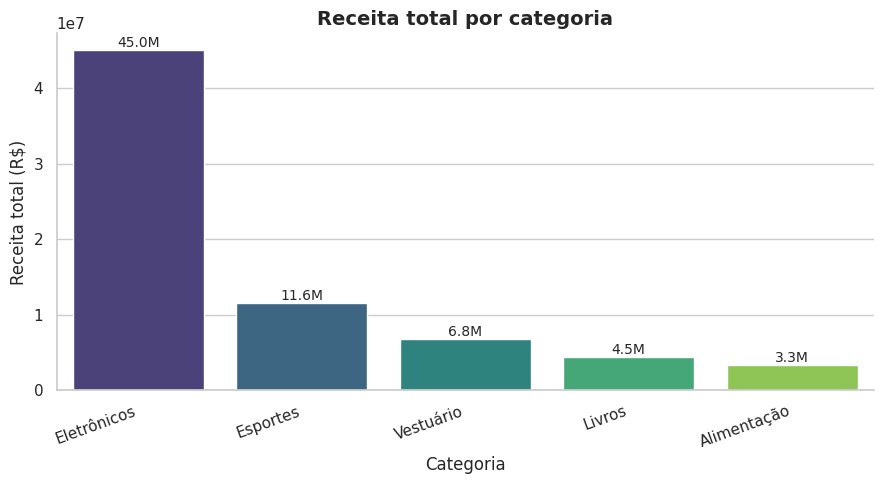

In [26]:
receita_categoria = df.groupby("categoria")["receita_total"].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=receita_categoria.index, y=receita_categoria.values,
    hue=receita_categoria.index, palette="viridis", legend=False
)
sns.despine()

for i, valor in enumerate(receita_categoria.values):
    ax.text(i, valor, f"{valor/1e6:.1f}M", ha="center", va="bottom", fontsize=10)

plt.title("Receita total por categoria", fontsize=14, fontweight="bold")
plt.xlabel("Categoria")
plt.ylabel("Receita total (R$)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

**Interpretação:** o gráfico deixa evidente o domínio da categoria Eletrônicos, com receita total muito acima das demais categorias — reflexo do ticket médio mais alto desse tipo de produto. Alimentação é a categoria com menor receita total no período.

### B. Gráfico de linha — Evolução da receita ao longo do tempo

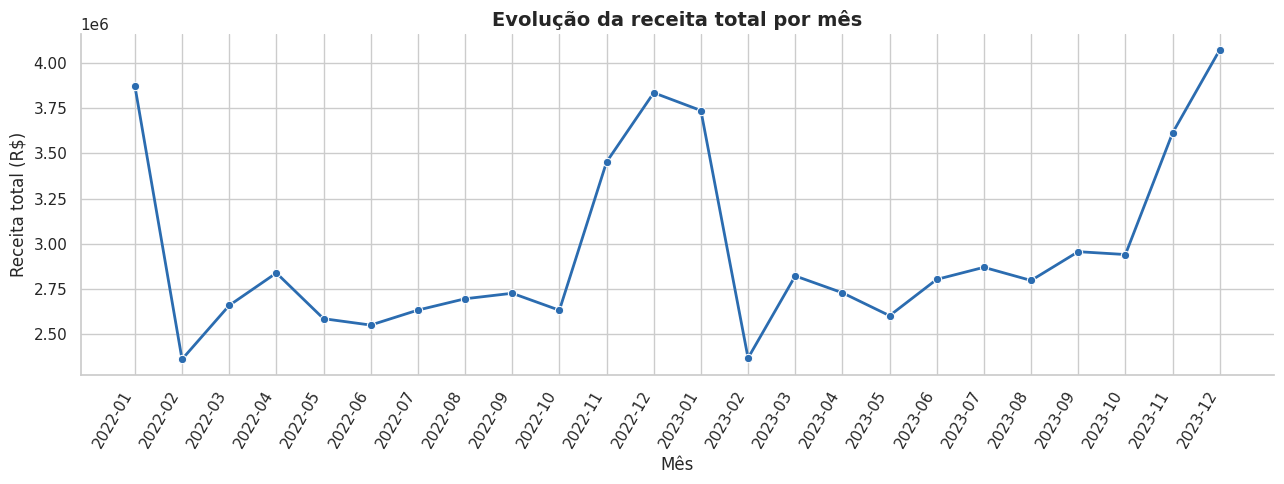

In [27]:
df["ano_mes"] = df["data_venda"].dt.to_period("M").astype(str)
receita_mensal = df.groupby("ano_mes")["receita_total"].sum().sort_index()

plt.figure(figsize=(13, 5))
sns.lineplot(x=receita_mensal.index, y=receita_mensal.values, marker="o", linewidth=2, color="#2b6cb0")
sns.despine()

plt.title("Evolução da receita total por mês", fontsize=14, fontweight="bold")
plt.xlabel("Mês")
plt.ylabel("Receita total (R$)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

**Interpretação:** a receita mensal oscila ao longo dos dois anos do dataset, sem uma tendência clara e constante de crescimento, mas com picos pontuais que podem estar associados a períodos de alta temporada — algo que poderia ser aprofundado cruzando com a coluna `alta_temporada`.

### C. Gráfico de dispersão — Desconto x Receita

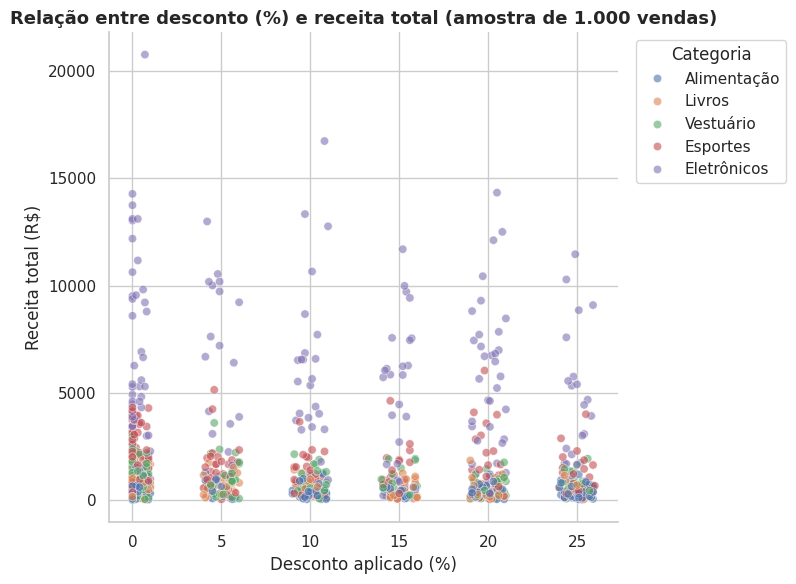

In [28]:
amostra = df.sample(n=1000, random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=amostra, x="desconto_pct", y="receita_total", hue="categoria", alpha=0.6)
sns.despine()

plt.title("Relação entre desconto (%) e receita total (amostra de 1.000 vendas)", fontsize=13, fontweight="bold")
plt.xlabel("Desconto aplicado (%)")
plt.ylabel("Receita total (R$)")
plt.legend(title="Categoria", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Interpretação:** usamos uma amostra de 1.000 vendas para não poluir o gráfico. Não há uma relação linear clara entre o percentual de desconto e a receita total — vendas com receita alta aparecem tanto com desconto baixo quanto alto, o que sugere que a receita é mais influenciada pelo preço/quantidade do produto do que pelo desconto em si.

### D. Mapa de calor — Correlação entre variáveis numéricas

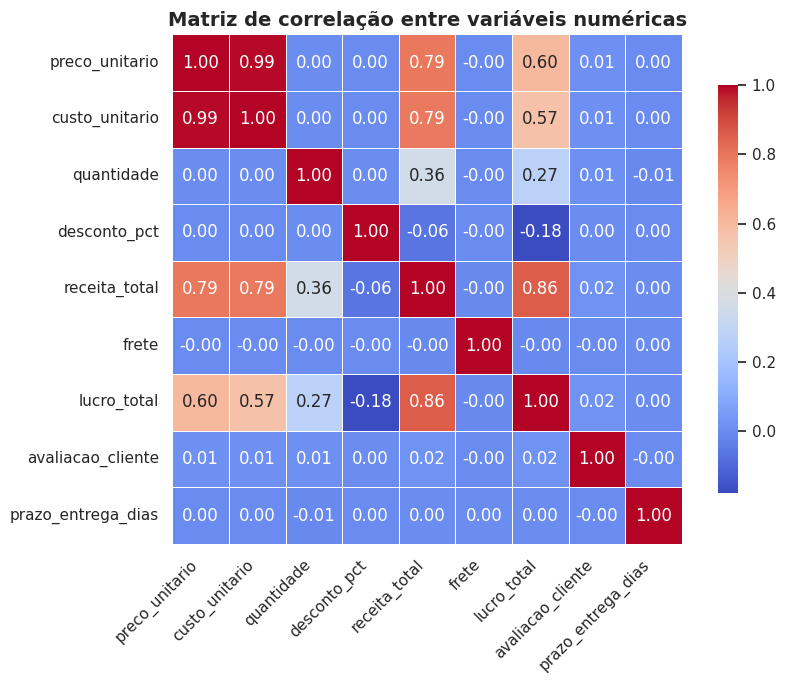

In [29]:
colunas_numericas = [
    "preco_unitario", "custo_unitario", "quantidade", "desconto_pct",
    "receita_total", "frete", "lucro_total", "avaliacao_cliente", "prazo_entrega_dias",
]
correlacao = df[colunas_numericas].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(correlacao, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})

plt.title("Matriz de correlação entre variáveis numéricas", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Interpretação:** como esperado, `receita_total` tem correlação forte e positiva com `preco_unitario` e `lucro_total` — quanto maior o preço do produto, maior tende a ser a receita e o lucro da venda. Já `desconto_pct`, `avaliacao_cliente` e `prazo_entrega_dias` apresentam correlação próxima de zero com as demais variáveis, indicando que não têm relação linear forte com o valor financeiro da venda.

#### Conclusão final

Ao longo do notebook, usamos NumPy para cálculos numéricos vetorizados, Pandas para limpar e transformar o dataset (tratando datas em múltiplos formatos, cidades escritas de forma inconsistente e valores faltantes) e Seaborn para visualizar os principais padrões. O quadro geral que emerge é o de uma operação de vendas fortemente concentrada na categoria Eletrônicos, com canais digitais (Site Web e App Mobile) liderando em volume, receita razoavelmente distribuída entre as regiões do Brasil, e o preço do produto — muito mais do que o desconto aplicado — como o principal fator associado à receita e ao lucro de cada venda.